In [112]:
import tensorflow as tf
import numpy as n
import gymnasium as gym
from collections import deque
import random
import matplotlib.pyplot as plt

In [113]:
gpus = tf.config.list_physical_devices("GPU")

print("GPUs:", gpus)

if len(gpus) >= 2:
    strategy = tf.distribute.MirroredStrategy(
        devices=["/GPU:0", "/GPU:1"]
    )
else:
    strategy = tf.distribute.get_strategy()

print("Number of replicas:", strategy.num_replicas_in_sync)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of replicas: 2


In [114]:
state_dim = 4
n_outputs = 2

learning_rate = 0.001
gamma = 0.95

batch_size = 64

episodes = 600
max_steps = 200

epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 500

target_update_frequency = 10


In [115]:
def create_dueling_dqn():

    inputs = tf.keras.layers.Input(shape=(state_dim,))

    hidden1 = tf.keras.layers.Dense(
        32,
        activation="elu"
    )(inputs)

    hidden2 = tf.keras.layers.Dense(
        32,
        activation="elu"
    )(hidden1)

    state_value = tf.keras.layers.Dense(
        1
    )(hidden2)

    raw_advantages = tf.keras.layers.Dense(
        n_outputs
    )(hidden2)

    advantages = tf.keras.layers.Lambda(
        lambda x: x - tf.reduce_mean(
            x,
            axis=1,
            keepdims=True
        )
    )(raw_advantages)

    # Q(s,a) = V(s) + A(s,a)
    outputs = state_value + advantages

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs
    )



In [116]:
with strategy.scope():

    model = create_dueling_dqn()

    target_model = create_dueling_dqn()

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model(tf.zeros((1, state_dim)))
    target_model(tf.zeros((1, state_dim)))

    target_model.set_weights(
        model.get_weights()
    )


    optimizer.build(
        model.trainable_variables
    )


print("Models and optimizer initialized.")



Models and optimizer initialized.


In [117]:
env = gym.make("CartPole-v1")

In [118]:
replay_buffer = deque(
    maxlen=2000
)

In [119]:
def epsilon_greedy_policy(state, epsilon):

    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)

    state_tensor = tf.convert_to_tensor(
        state[None],
        dtype=tf.float32
    )

    q_values = model(
        state_tensor,
        training=False
    )

    return int(
        tf.argmax(
            q_values[0]
        ).numpy()
    )



In [120]:
def play_one_step(env, state, epsilon):

    action = epsilon_greedy_policy(
        state,
        epsilon
    )

    next_state, reward, terminated, truncated, info = env.step(action)

    done = terminated or truncated

    replay_buffer.append(
        (
            state,
            action,
            reward,
            next_state,
            done
        )
    )

    return next_state, reward, done

In [121]:
def sample_experiences(batch_size):

    experiences = random.sample(
        replay_buffer,
        batch_size
    )

    states = np.array(
        [e[0] for e in experiences],
        dtype=np.float32
    )

    actions = np.array(
        [e[1] for e in experiences],
        dtype=np.int32
    )

    rewards = np.array(
        [e[2] for e in experiences],
        dtype=np.float32
    )

    next_states = np.array(
        [e[3] for e in experiences],
        dtype=np.float32
    )

    dones = np.array(
        [e[4] for e in experiences],
        dtype=np.float32
    )

    return (
        states,
        actions,
        rewards,
        next_states,
        dones
    )


In [122]:
with strategy.scope():

    @tf.function
    def replica_train_step(
        states,
        actions,
        rewards,
        next_states,
        dones
    ):

        with tf.GradientTape() as tape:



            q_values = model(
                states,
                training=True
            )

            # Select Q(s,a)
            action_mask = tf.one_hot(
                actions,
                n_outputs
            )

            current_q = tf.reduce_sum(
                q_values * action_mask,
                axis=1
            )



            next_q_values = target_model(
                next_states,
                training=False
            )

            max_next_q = tf.reduce_max(
                next_q_values,
                axis=1
            )

            target_q = rewards + (
                gamma *
                max_next_q *
                (1.0 - dones)
            )



            loss = tf.reduce_mean(
                tf.square(
                    target_q - current_q
                )
            )


        gradients = tape.gradient(
            loss,
            model.trainable_variables
        )

        optimizer.apply_gradients(
            zip(
                gradients,
                model.trainable_variables
            )
        )

        return loss



In [123]:
@tf.function
def distributed_train_step(
    states,
    actions,
    rewards,
    next_states,
    dones
):

    per_replica_loss = strategy.run(
        replica_train_step,
        args=(
            states,
            actions,
            rewards,
            next_states,
            dones
        )
    )

    return strategy.reduce(
        tf.distribute.ReduceOp.MEAN,
        per_replica_loss,
        axis=None
    )

In [124]:
episode_rewards = []
losses = []

for episode in range(episodes):

    state, info = env.reset()

    total_reward = 0

    epsilon = max(
        epsilon_end,
        epsilon_start -
        episode / epsilon_decay
    )

    for step in range(max_steps):

        state, reward, done = play_one_step(
            env,
            state,
            epsilon
        )

        total_reward += reward

        if len(replay_buffer) >= batch_size:

            (
                states,
                actions,
                rewards,
                next_states,
                dones
            ) = sample_experiences(
                batch_size
            )

            loss = distributed_train_step(
                tf.convert_to_tensor(
                    states,
                    dtype=tf.float32
                ),
                tf.convert_to_tensor(
                    actions,
                    dtype=tf.int32
                ),
                tf.convert_to_tensor(
                    rewards,
                    dtype=tf.float32
                ),
                tf.convert_to_tensor(
                    next_states,
                    dtype=tf.float32
                ),
                tf.convert_to_tensor(
                    dones,
                    dtype=tf.float32
                )
            )

            losses.append(
                float(loss.numpy())
            )

        if done:
            break

    episode_rewards.append(total_reward)



    if episode % target_update_frequency == 0:

        with strategy.scope():
            target_model.set_weights(
                model.get_weights()
            )

    print(
        f"Episode {episode + 1:3d} | "
        f"Reward: {total_reward:3.0f} | "
        f"Epsilon: {epsilon:.3f}"
    )



env.close()



Episode   1 | Reward:  17 | Epsilon: 1.000
Episode   2 | Reward:  14 | Epsilon: 0.998
Episode   3 | Reward:  12 | Epsilon: 0.996
INFO:tensorflow:Collective all_reduce tensors: 8 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Episode   4 | Reward:  62 | Epsilon: 0.994
Episode   5 | Reward:  36 | Epsilon: 0.992
Episode   6 | Reward:  17 | Epsilon: 0.990
Episode   7 | Reward:  36 | Epsilon: 0.988
Episode   8 | Reward:  17 | Epsilon: 0.986
Episode   9 | Reward:  11 | Epsilon: 0.984
Episode  10 | Reward:  30 | Epsilon: 0.982
Episode  11 | Reward:  12 | Epsilon: 0.980
Episode  12 | Reward:  15 | Epsilon: 0.978
Episode  13 | Reward:  29 | Epsilon: 0.976
Episode  14 | Reward:  15 | Epsilon: 0.974
Episode  15 | Reward:  13 | Epsilon: 0.972
Episode  16 | Reward:  19 | Epsilon: 0.970
Episode  17 

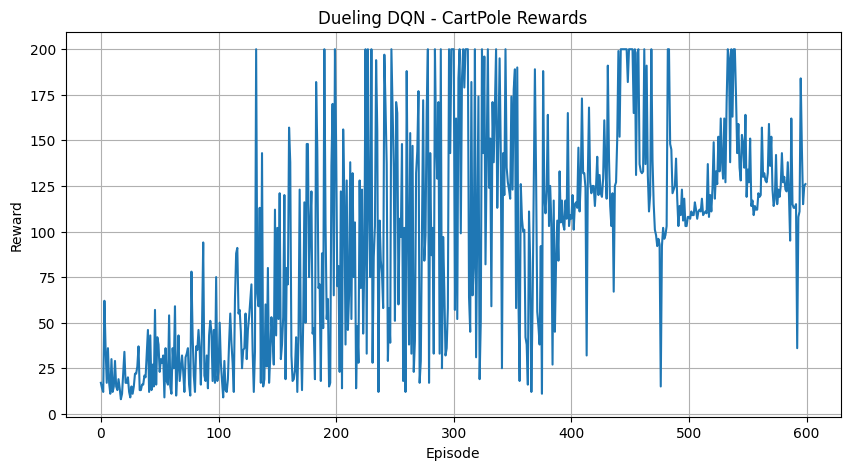

In [125]:

plt.figure(figsize=(10, 5))

plt.plot(
    episode_rewards
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Dueling DQN - CartPole Rewards")

plt.grid()

plt.show()



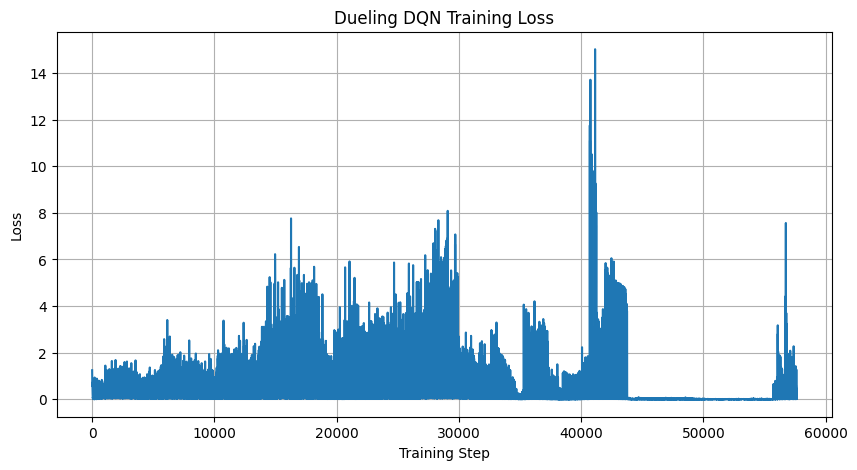

In [126]:

plt.figure(figsize=(10, 5))

plt.plot(
    losses
)

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Dueling DQN Training Loss")

plt.grid()

plt.show()